Bloco 01: Extraindo os dados e importando em array no Pandas

In [22]:
import pandas as pd
import numpy as np

#Busca os dados na internet e transforma numa tabela (DataFrame)
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)
print(df)

#Conta quantas transações são Classe 0 (Normais) e Classe 1 (Fraudes)
contagem = df["Class"].value_counts()
quantidade_de_normais = contagem[0]
quantidade_de_fraudes = contagem[1]

#Descobre o peso da balança (578 normais para 1 fraude)
proporcao = quantidade_de_normais / quantidade_de_fraudes

print(df["Class"].value_counts(normalize=True)) 
print(f"Existe cerca de {proporcao:.0f} transações normais para cada 1 fraude.")

            Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V21       V22  \
0       0.462388  0.239599  0.098698  0.363787  ... -0.01830

Bloco 02: 

Separando os dados que serão utilizados para treino (30%) e dados que serão utilizados para teste dos modelos (70%).

In [23]:
from sklearn.model_selection import train_test_split

#O 'X' são as pistas (colunas V1, V2, Amount_scaled...)
X = df.drop("Class", axis=1)

#O 'y' é a resposta que queremos adivinhar (É fraude ou não?)
y = df["Class"]

#Separa 70% para Treino (estudo) e 30% para Teste (prova)
X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=0.3, random_state=42 
)

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")

Treino: (199364, 30) | Teste: (85443, 30)


Bloco 03: 

Utilizando técnicas de desbalanceamento de classes.

In [24]:
from imblearn.over_sampling import SMOTE

# Junta as features e o target de treino para fazer o undersampling isoladamente
df_train = X_train.copy()
df_train["Class"] = y_train

# Undersampling (utilizando apenas df_train)
fraudes = df_train[df_train["Class"] == 1]
normais = df_train[df_train["Class"] == 0].sample(len(fraudes), random_state=42)

# Junta as fraudes com o grupo pequeno de normais
df_under = pd.concat([fraudes, normais])
X_under = df_under.drop("Class", axis=1)
y_under = df_under["Class"]

#Oversampling (Criar clones das fraudes com SMOTE)
smote = SMOTE(random_state=42)

# O SMOTE cria os clones apenas nos dados de estudo (Treino)
X_res, y_res = smote.fit_resample(X_train, y_train)

Bloco 04: Modelo 1, Logistic Regression.

O mais simples, traça uma linha reta para separar os dados.

Obs.: Foi utilizado o StandardScaler neste bloco e no bloco 06 para escalonar os pesos entre transações que "É Fraude" e "Não é Fraude" para os modelos analisar a importância real das coisas, e não apenas o tamanho do número.

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Pipeline para Regressão Logística
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()), 
    ('smote', SMOTE(random_state=42)),
    ('logreg', LogisticRegression(solver='saga', max_iter=1000, random_state=42))
])

model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)
y_pred_rf = model.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.85      0.63      0.72       148

    accuracy                           1.00     85443
   macro avg       0.92      0.81      0.86     85443
weighted avg       1.00      1.00      1.00     85443



c:\Users\Pat\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Bloco 05: Modelo 2, Random Forest Classifier (intermediário).

"Uma 'floresta' de várias árvores de decisão".

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier (
    n_estimators=50,
    max_depth=10,
    class_weight="balanced", #Tenta equilibrar o peso das fraudes automaticamente
    random_state=42
)

rf.fit (X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("--- Random Forest ---")
print (classification_report(y_test, y_pred_rf))

--- Random Forest ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.71      0.80      0.75       148

    accuracy                           1.00     85443
   macro avg       0.86      0.90      0.88     85443
weighted avg       1.00      1.00      1.00     85443



Bloco 06: Modelo 3, XGBoost (melhor desempenho).

In [27]:
from xgboost import XGBClassifier

#Pipeline para XGBoost
pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])

#O XGBoost usa a proporção que calculamos lá em cima (578). 
#Isso diz a ele: "Errar uma fraude é 578 vezes pior que errar uma transação normal!"
xgb = XGBClassifier(
    scale_pos_weight=proporcao,
    eval_metric="logloss"
)
xgb.fit(X_train, y_train)

#Pegamos a probabilidade matemática de ser fraude (ao invés da resposta final 0 ou 1)
y_probs = xgb.predict_proba(X_test)[:,1]

#Baixamos a régua: se tiver 20% (0.20) de chance, classificamos como fraude
y_prob_xgb = (y_probs > 0.20).astype(int)

print("--- XGBoost com Régua de 20% ---")
print(classification_report(y_test, y_prob_xgb))

--- XGBoost com Régua de 20% ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.86      0.78      0.82       148

    accuracy                           1.00     85443
   macro avg       0.93      0.89      0.91     85443
weighted avg       1.00      1.00      1.00     85443



Bloco 07: 

Criando dados com SMOTE no XGBoost. Em seguida gerar dados com o Undersampling e Oversampling a fim para comparação

In [28]:
#Com Undersampling
xgb_under = XGBClassifier(eval_metric="logloss")
xgb_under.fit(X_under, y_under)
print("Resultado com Undersampling:")
print(classification_report(y_test, xgb_under.predict(X_test)))

#Com Oversampling
xgb_smote = XGBClassifier(eval_metric="logloss")
xgb_smote.fit(X_res, y_res) # Treina com o resampled!

#Previsão no X_test normal.
y_pred_smote = xgb_smote.predict(X_test)
print("Resultado com Oversampling:")
print(classification_report(y_test, y_pred_smote))

Resultado com Undersampling:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     85295
           1       0.04      0.90      0.08       148

    accuracy                           0.96     85443
   macro avg       0.52      0.93      0.53     85443
weighted avg       1.00      0.96      0.98     85443

Resultado com Oversampling:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.82      0.82      0.82       148

    accuracy                           1.00     85443
   macro avg       0.91      0.91      0.91     85443
weighted avg       1.00      1.00      1.00     85443



Bloco 08: Grafico ROC

Uma analise da taxa do Falso Positivo e Verdadeiro Positivo

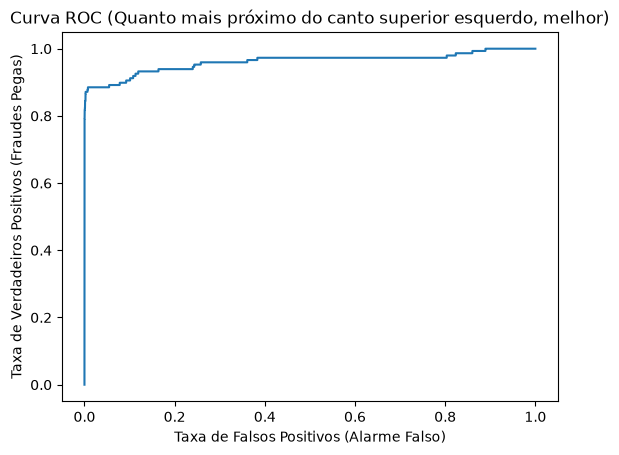

AUC (Nota geral do modelo de 0 a 1): 0.9613151811756654


In [29]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

#A Curva ROC mostra o equilíbrio entre acertar as fraudes e não dar alarme falso demais
y_probs = xgb.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("Curva ROC (Quanto mais próximo do canto superior esquerdo, melhor)")
plt.xlabel("Taxa de Falsos Positivos (Alarme Falso)")
plt.ylabel("Taxa de Verdadeiros Positivos (Fraudes Pegas)")
plt.show()

print("AUC (Nota geral do modelo de 0 a 1):", roc_auc_score(y_test, y_probs))


Bloco 09: Grafico Precision-Recall

Gráfico de Curva de Recall por Precição 

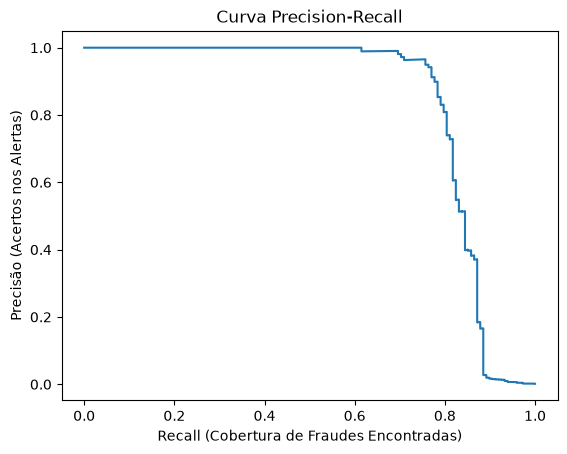

In [30]:
from sklearn.metrics import precision_recall_curve

#Esse gráfico é o mais importante para fraudes!
#Recall = Quantas fraudes o modelo achou.
#Precision = Quando o modelo apitou, ele estava certo?
precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Curva Precision-Recall")
plt.ylabel("Precisão (Acertos nos Alertas)")
plt.xlabel("Recall (Cobertura de Fraudes Encontradas)")
plt.show()

Bloco 10: Gráfico SHAP 1

Grafico de SHAP em barras

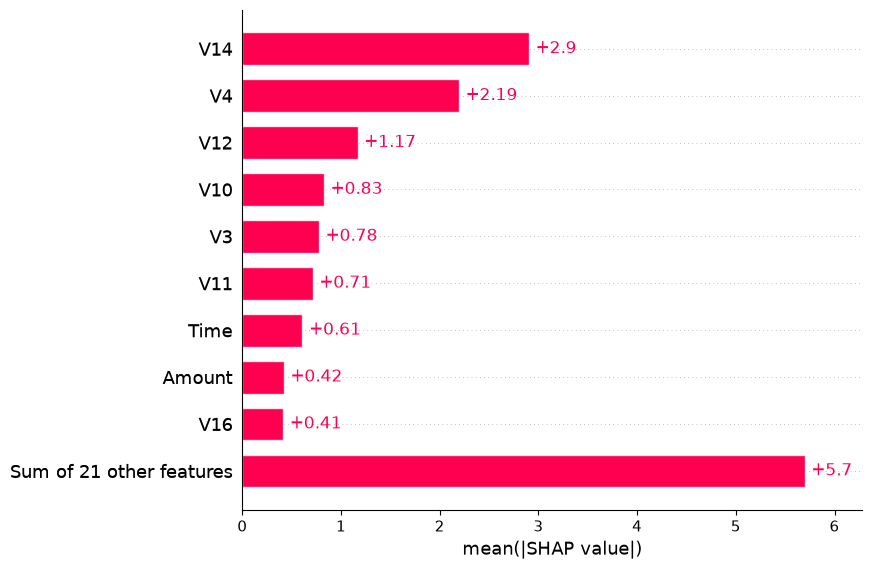

In [31]:
import shap 

#O Explainer vai olhar para o modelo XGBoost e tentar entender como ele pensa
explainer = shap.Explainer(xgb)
#Vamos analisar apenas as 100 primeiras transações de teste para o computador não travar
shap_values = explainer(X_test[:100])

#Cria o gráfico de barras que mostra quais características (colunas) mais denunciam uma fraude
shap.plots.bar(shap_values)

Bloco 11: Gráfico SHAP 2

Grafico de SHAP em diagrama de dispersão categórico onde os pontos são ajustados para não se sobreporem, mostrando a distribuição dos dados.

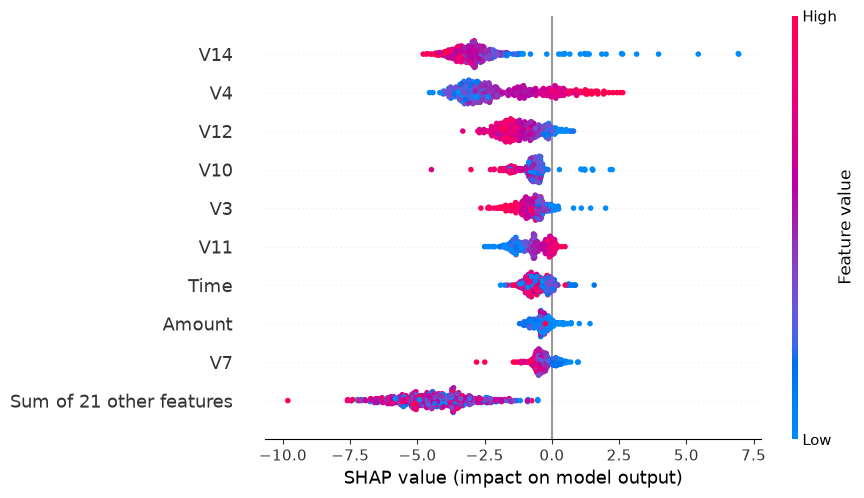

In [32]:
import shap 
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test[:500])

shap.plots.beeswarm(shap_values)

Bloco 12: Gráfico SHAP 3

Grafico de SHAP em cascata.

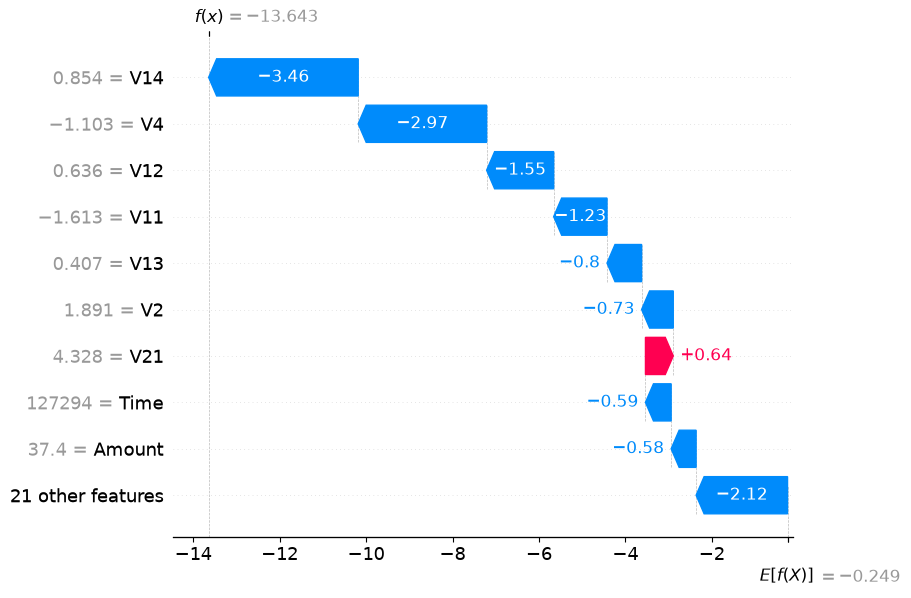

In [33]:
transacao_numero = 0

shap.plots.waterfall(shap_values[transacao_numero])

Bloco 13: Validação Cruzada Rigorosa

Em vez de treinar diretamente, validamos a consistência do Pipeline de XGBoost em 5 cortes diferentes dos dados de treino, avaliando pela métrica de Área sob a Curva Precision-Recall (AUPRC).

In [34]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# Cria os 5 cortes estratificados
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Avalia o modelo usando a métrica AUPRC (average_precision)
cv_scores = cross_val_score(
    pipeline_xgb, X_train, y_train, cv=skf, scoring='average_precision', n_jobs=-1
)

print(f"Scores AUPRC na Validação Cruzada: {cv_scores}")
print(f"AUPRC Médio: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Scores AUPRC na Validação Cruzada: [0.87400352 0.85320562 0.87018904 0.84480726 0.78214907]
AUPRC Médio: 0.8449 (+/- 0.0331)


Bloco 14: Treinamento Final e Visualização do Impacto (Matriz de Confusão)

Treinando o modelo na base de treino completa e extração das métricas finais na base de teste. O gráfico de matriz de confusão deixa cristalino o trade-off entre bloquear clientes reais e deixar fraudes passarem.

c:\Users\Pat\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:49:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


AUC-PR no Teste: 0.8281

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.79      0.80      0.80       148

    accuracy                           1.00     85443
   macro avg       0.89      0.90      0.90     85443
weighted avg       1.00      1.00      1.00     85443



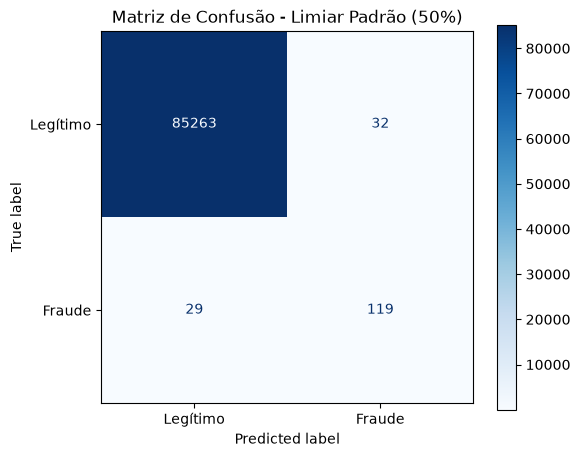

In [35]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, average_precision_score 

# Treina o pipeline (o scaler e o smote são aplicados internamente apenas no X_train)
pipeline_xgb.fit(X_train, y_train)

# Previsões padrão (limiar de 50%)
y_pred_xgb = pipeline_xgb.predict(X_test)
y_proba_xgb = pipeline_xgb.predict_proba(X_test)[:, 1]

# Calcula a métrica AUPRC no Teste
auprc_test = average_precision_score(y_test, y_proba_xgb)
print(f"AUC-PR no Teste: {auprc_test:.4f}\n")
print(classification_report(y_test, y_pred_xgb))

# Plota a Matriz de Confusão
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb, 
    display_labels=['Legítimo', 'Fraude'], 
    cmap='Blues', ax=ax
)
plt.title("Matriz de Confusão - Limiar Padrão (50%)")
plt.show()

Bloco 15: Ajuste de Limiar (Threshold de Negócio)

Este é o refinamento final de negócio. Alteramos a régua de probabilidade para 20% para capturar mais fraudes, aceitando um leve aumento nos falsos positivos.

Relatório de Classificação com Limiar de 20.0%:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.60      0.83      0.70       148

    accuracy                           1.00     85443
   macro avg       0.80      0.92      0.85     85443
weighted avg       1.00      1.00      1.00     85443



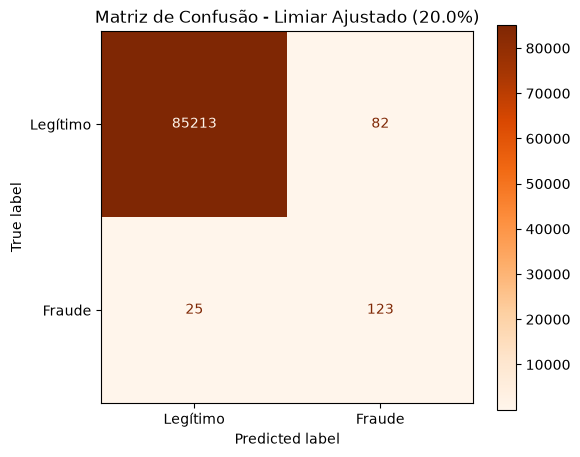

In [36]:
# Define o novo limiar (20%)
limiar_negocio = 0.20

# Aplica a regra: se a probabilidade for maior que 20%, classifica como fraude (1)
y_pred_custom = (y_proba_xgb >= limiar_negocio).astype(int)

print(f"Relatório de Classificação com Limiar de {limiar_negocio*100}%:\n")
print(classification_report(y_test, y_pred_custom))

# Plota a nova Matriz de Confusão para comparar o impacto
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_custom, 
    display_labels=['Legítimo', 'Fraude'], 
    cmap='Oranges', ax=ax
)
plt.title(f"Matriz de Confusão - Limiar Ajustado ({limiar_negocio*100}%)")
plt.show()